# 📈 03.1: Ejemplos Adicionales de Regresión Lineal

Este notebook contiene ejemplos prácticos adicionales para afianzar el concepto de **Regresión Lineal** utilizando `scikit-learn`.

**Objetivos:**
- Repasar el flujo de trabajo de Machine Learning en diferentes escenarios.
- Implementar modelos de regresión lineal simple.
- Introducir y aplicar la regresión lineal múltiple (con más de una variable predictora).

In [2]:
# Importar librerías fundamentales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

--- 
### 💵 Ejemplo 1: Predicción de Salario basado en Años de Experiencia

**Problema**: Tenemos datos de empleados con sus años de experiencia y su salario actual. Queremos construir un modelo que prediga el salario de un empleado basándose en su experiencia.

Datos de Salario vs Experiencia:


,AñosExperiencia,Salario
0,1.516399,27491.151918
1,2.570668,46553.948220
2,3.028474,47786.438603
3,4.171522,47912.605615
4,5.685277,59369.861456


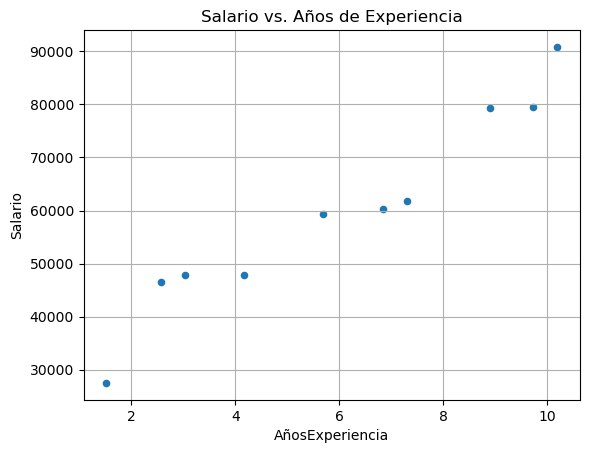

Modelo entrenado. Intercepto: 20930.19, Coeficiente: 6455.48
Error Absoluto Medio en el test: 6577.29€


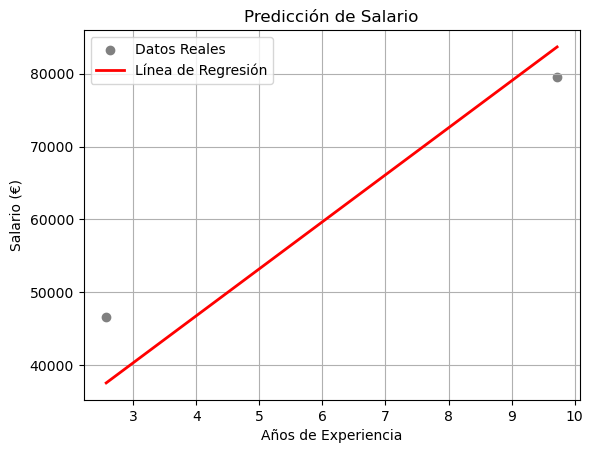


Predicción de salario para 12 años de experiencia: 98395.92€


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
# 1. Creación de datos sintéticos
np.random.seed(101)
experiencia = np.arange(1, 11) + np.random.rand(10) # Años de experiencia (1 a 10 con ruido)
salario = 30000 + experiencia * 5000 + np.random.normal(0, 5000, 10) # Salario base + bonus por experiencia + ruido

df_salario = pd.DataFrame({'AñosExperiencia': experiencia, 'Salario': salario})

# 2. Análisis Exploratorio (EDA)
print("Datos de Salario vs Experiencia:")
display(df_salario.head())

df_salario.plot(x='AñosExperiencia', y='Salario', kind='scatter', title='Salario vs. Años de Experiencia')
plt.grid(True)
plt.show()

# 3. Preparación y División de Datos
X_exp = df_salario[['AñosExperiencia']]
y_sal = df_salario['Salario']
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp, y_sal, test_size=0.2, random_state=42)

# 4. Entrenamiento del Modelo
modelo_salario = LinearRegression()
modelo_salario.fit(X_train_exp, y_train_exp)
print(f"Modelo entrenado. Intercepto: {modelo_salario.intercept_:.2f}, Coeficiente: {modelo_salario.coef_[0]:.2f}")

# 5. Evaluación y Visualización
predicciones_salario = modelo_salario.predict(X_test_exp)
error_medio_salario = metrics.mean_absolute_error(y_test_exp, predicciones_salario)
print(f"Error Absoluto Medio en el test: {error_medio_salario:.2f}€")

plt.scatter(X_test_exp, y_test_exp, color='gray', label='Datos Reales')
plt.plot(X_test_exp, predicciones_salario, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Predicción de Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (€)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Hacer una nueva predicción
experiencia_nueva = 12
salario_predicho = modelo_salario.predict([[experiencia_nueva]])
print(f"\nPredicción de salario para {experiencia_nueva} años de experiencia: {salario_predicho[0]:.2f}€")

--- 
### 💻 Ejemplo 2: Regresión Lineal Múltiple - Precios de Portátiles

**Problema**: Ahora, el precio no depende de una sola cosa. Queremos predecir el precio de un portátil basándonos en su **RAM (en GB)** y la **velocidad de su CPU (en GHz)**.

Esto es un ejemplo de **Regresión Lineal Múltiple**, porque usamos más de una variable predictora (`X`).

In [5]:
# 1. Creación de datos sintéticos
np.random.seed(42) # Fija la semilla para que los resultados aleatorios sean siempre los mismos.
# Generamos 100 valores de RAM, eligiendo aleatoriamente entre 8, 16 y 32 GB.
ram = np.random.choice([8, 16, 32], 100) 
# Generamos 100 valores de velocidad de CPU, con una distribución uniforme entre 2.5 y 4.5 GHz.
cpu_ghz = np.random.uniform(2.5, 4.5, 100) 
# Creamos el precio con una fórmula lineal: un precio base + un coste por GB de RAM + un coste por GHz de CPU + un "ruido" aleatorio.
precio = 200 + ram * 50 + cpu_ghz * 150 + np.random.normal(0, 100, 100)

# Guardamos los datos en un DataFrame de Pandas para facilitar su manipulación.
df_portatiles = pd.DataFrame({'RAM_GB': ram, 'CPU_GHz': cpu_ghz, 'Precio': precio})

# 2. Análisis Exploratorio (EDA)
print("Datos de Portátiles:")
# Mostramos las primeras 5 filas para verificar que los datos se han cargado correctamente.
display(df_portatiles.head())

# 3. Preparación y División de Datos
# Seleccionamos las variables predictoras (features). Usamos dobles corchetes para que X sea un DataFrame.
X_portatil = df_portatiles[['RAM_GB', 'CPU_GHz']]
# Seleccionamos la variable objetivo (target), que es la que queremos predecir.
y_portatil = df_portatiles['Precio']

# Dividimos los datos: 80% para entrenar el modelo y 20% para evaluarlo.
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_portatil, y_portatil, test_size=0.2, random_state=42)

# 4. Entrenamiento del Modelo
# Creamos una instancia del modelo de Regresión Lineal.
modelo_portatil = LinearRegression()
# Entrenamos el modelo con los datos de entrenamiento. El método 'fit' encuentra los mejores coeficientes.
modelo_portatil.fit(X_train_p, y_train_p)

# El modelo aprende un coeficiente para cada variable predictora.
print("\nModelo Múltiple Entrenado:")
# El intercepto es el valor base del precio si RAM y CPU fueran 0.
print(f"Intercepto: {modelo_portatil.intercept_:.2f}")
# El primer coeficiente corresponde a la primera columna de X ('RAM_GB').
print(f"Coeficiente para RAM_GB: {modelo_portatil.coef_[0]:.2f}€ por cada GB de RAM")
# El segundo coeficiente corresponde a la segunda columna de X ('CPU_GHz').
print(f"Coeficiente para CPU_GHz: {modelo_portatil.coef_[1]:.2f}€ por cada GHz de CPU")

# 5. Evaluación
# Usamos el modelo entrenado para hacer predicciones sobre el conjunto de prueba (datos que no ha visto antes).
predicciones_portatil = modelo_portatil.predict(X_test_p)
# Calculamos el Error Absoluto Medio (MAE): la media de la diferencia absoluta entre el precio real y el predicho.
error_medio_portatil = metrics.mean_absolute_error(y_test_p, predicciones_portatil)
print(f"\nError Absoluto Medio en el test: {error_medio_portatil:.2f}€ (en promedio, el modelo se equivoca en esta cantidad)")

# 6. Hacer una nueva predicción
# Definimos las características de un nuevo portátil.
ram_nueva = 16 # 16 GB de RAM
cpu_nueva = 4.0 # 4.0 GHz de CPU
# Creamos un array 2D, ya que el modelo espera un formato de múltiples muestras.
portatil_nuevo = [[ram_nueva, cpu_nueva]]
# El modelo calcula el precio predicho usando sus coeficientes aprendidos.
precio_predicho_portatil = modelo_portatil.predict(portatil_nuevo)
print(f"\nPredicción de precio para un portátil con {ram_nueva}GB RAM y {cpu_nueva}GHz CPU: {precio_predicho_portatil[0]:.2f}€")

Datos de Portátiles:


,RAM_GB,CPU_GHz,Precio
0,32,2.897431,2235.529139
1,8,2.511044,940.102705
2,32,4.130923,2484.547102
3,32,3.913715,2264.769849
4,8,3.958014,1247.335754



Modelo Múltiple Entrenado:
Intercepto: 221.78
Coeficiente para RAM_GB: 50.63€ por cada GB de RAM
Coeficiente para CPU_GHz: 144.25€ por cada GHz de CPU

Error Absoluto Medio en el test: 67.59€ (en promedio, el modelo se equivoca en esta cantidad)

Predicción de precio para un portátil con 16GB RAM y 4.0GHz CPU: 1608.85€


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


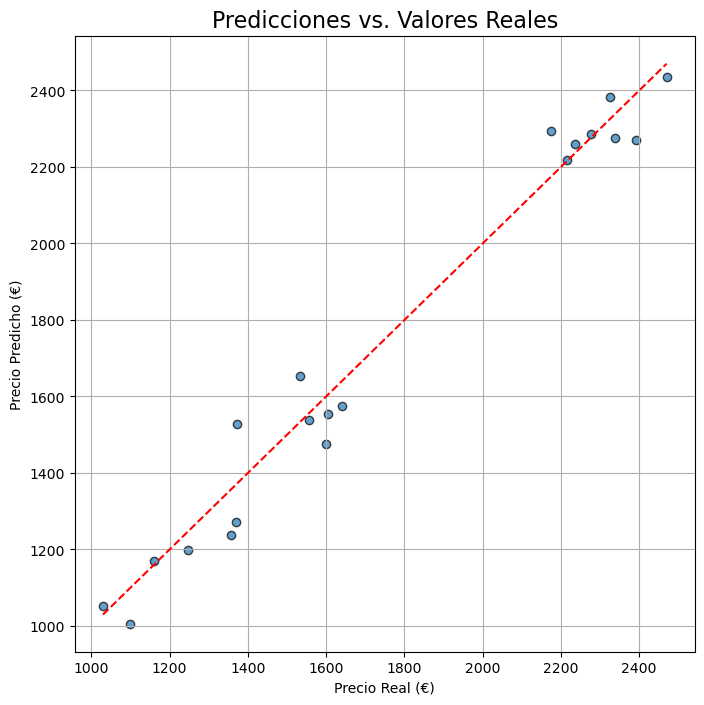

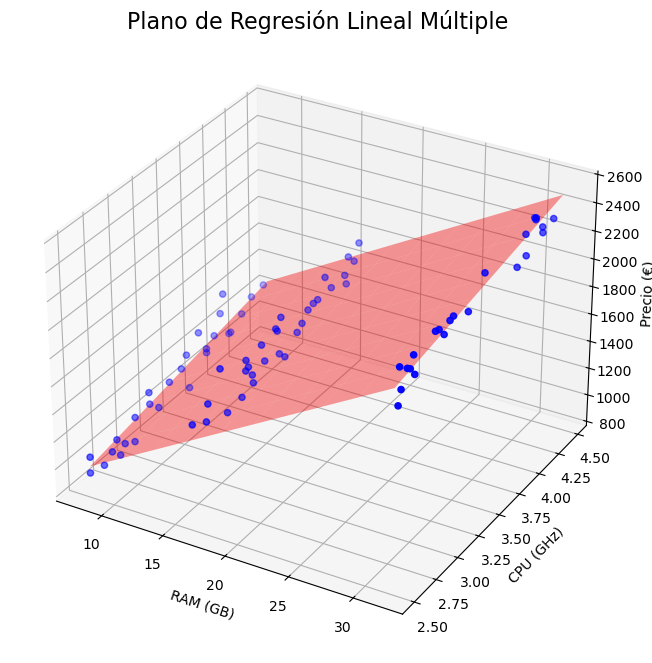

In [ ]:
# --- Visualización del Modelo Múltiple ---

# 1. Gráfico de Predicciones vs. Valores Reales
# Este gráfico es ideal para ver qué tan bueno es el modelo.
# Si los puntos se alinean cerca de la línea diagonal, el modelo es preciso.
plt.figure(figsize=(8, 8))
plt.scatter(y_test_p, predicciones_portatil, edgecolors='k')
# Dibujamos una línea de 45 grados que representa la predicción perfecta.
plt.plot([y_test_p.min(), y_test_p.max()], [y_test_p.min(), y_test_p.max()], 'r--')
plt.title('Predicciones vs. Valores Reales', fontsize=16)
plt.xlabel('Precio Real (€)')
plt.ylabel('Precio Predicho (€)')
plt.grid(True)
plt.show()

# 2. Gráfico 3D del Plano de Regresión
# Como tenemos dos variables predictoras, el modelo es un plano en 3D.

# Creamos los ejes para el plano 3D
ram_surf, cpu_surf = np.meshgrid(
    np.linspace(df_portatiles['RAM_GB'].min(), df_portatiles['RAM_GB'].max(), 10),
    np.linspace(df_portatiles['CPU_GHz'].min(), df_portatiles['CPU_GHz'].max(), 10)
)
# Usamos los coeficientes del modelo para definir la superficie del plano
precio_surf = modelo_portatil.intercept_ + modelo_portatil.coef_[0] * ram_surf + modelo_portatil.coef_[1] * cpu_surf

# Creamos la figura 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujamos los puntos de datos de entrenamiento
ax.scatter(X_train_p['RAM_GB'], X_train_p['CPU_GHz'], y_train_p, color='blue', label='Datos de Entrenamiento')
# Dibujamos el plano de regresión que el modelo ha aprendido
ax.plot_surface(ram_surf, cpu_surf, precio_surf, color='red', alpha=0.4, label='Plano de Regresión')

ax.set_title('Plano de Regresión Lineal Múltiple', fontsize=16)
ax.set_xlabel('RAM (GB)')
ax.set_ylabel('CPU (GHz)')
ax.set_zlabel('Precio (€)')
plt.show()

### 🤔 ¿Qué significan estos gráficos?

1.  **Gráfico de Predicciones vs. Valores Reales:**
    *   Este gráfico de dispersión es una de las formas más importantes de evaluar un modelo de regresión.
    *   En el **eje X** tenemos los precios reales de los portátiles del conjunto de prueba.
    *   En el **eje Y** tenemos los precios que nuestro modelo ha predicho para esos mismos portátiles.
    *   La **línea roja discontinua** representa la "predicción perfecta" (donde el precio real es igual al precio predicho).
    *   **Conclusión**: Cuanto más cerca estén los puntos azules de la línea roja, mejor será nuestro modelo. Vemos que los puntos siguen la tendencia de la línea, lo que indica que el modelo está haciendo un buen trabajo.

2.  **Gráfico 3D del Plano de Regresión:**
    *   Como estamos usando dos variables (`RAM` y `CPU`) para predecir una tercera (`Precio`), nuestro modelo no es una línea, sino un **plano en un espacio tridimensional**.
    *   Los **puntos azules** son los datos reales que usamos para entrenar el modelo.
    *   La **superficie roja** es el plano de regresión que `scikit-learn` ha calculado. Es la "mejor superficie plana" que se ajusta a todos esos puntos de datos.
    *   **Conclusión**: Este gráfico nos ayuda a visualizar cómo el modelo combina linealmente la RAM y la CPU para estimar el precio. El plano representa la fórmula: `Precio ≈ intercepto + (coef_RAM * RAM) + (coef_CPU * CPU)`.

--- 
### Conclusión

En este notebook, has practicado:
1.  **Regresión Lineal Simple**: Predecir una variable a partir de otra.
2.  **Regresión Lineal Múltiple**: Predecir una variable a partir de varias otras.

El proceso con `scikit-learn` es muy similar en ambos casos. La principal diferencia radica en la preparación de `X`, que pasa de tener una columna a tener múltiples columnas.